In [2]:
%pip install -q ipywidgets==8.1.1 numpy matplotlib opencv-python ipympl plotly

# import of the libraries
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import cv2 as cv
import time



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


# Non linear filtering, mathematical morphology, segmentation

We are going to follow a complete image processing that achieves of non linear filtering and different mathematical morphology operations (sort, segmentation and labelling). 

## Preprocessing

### Denoising

The goal is to compare the performance of linear versus non-linear filters, 
for the denoising of an image.

Write the python code in order to:
* read the _tapis.png_ noisy image
* filter it spatially by using a mean filter with kernel $(3 \times 3)$  
* filter it spatially by using a median filter with kernel $(3 \times 3)$ with _cv.medianBlur()_
* display the 175th rows of the 3 images  


image size = (480, 480, 3)
image size = (480, 480)
pixel type = uint8


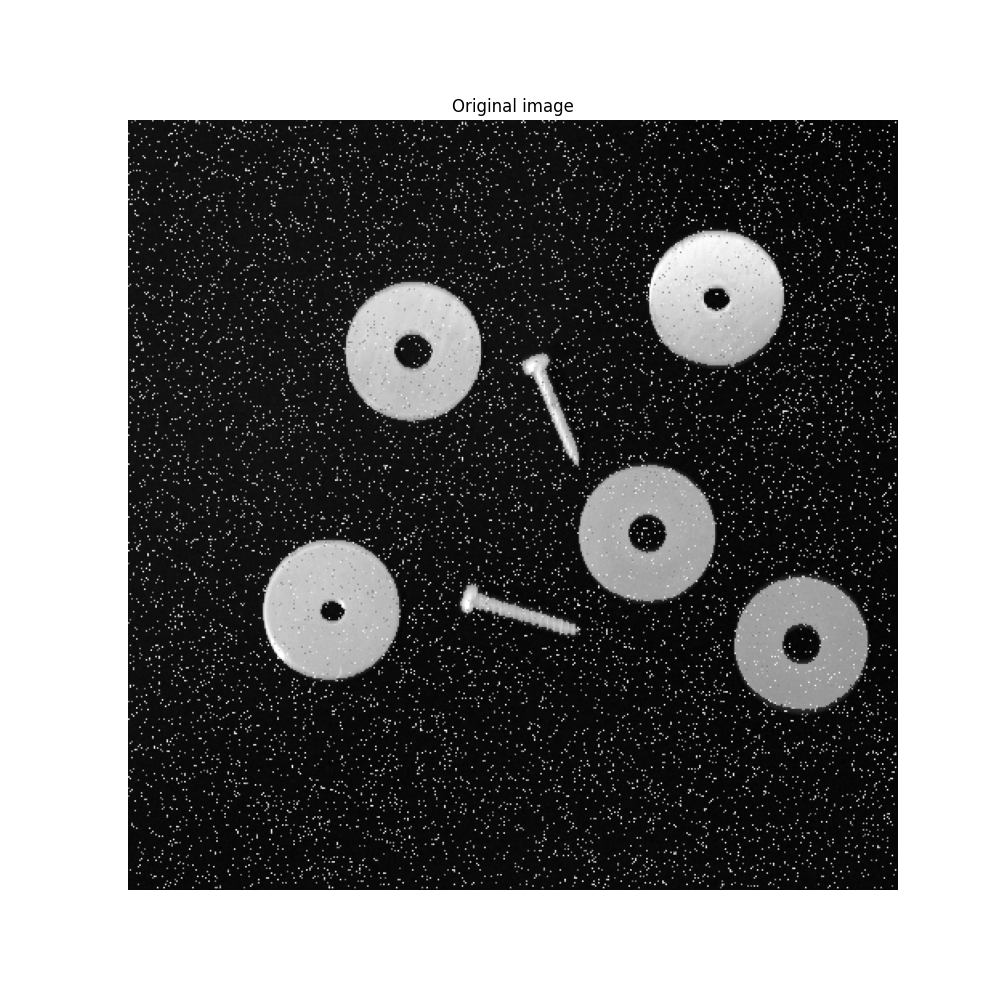

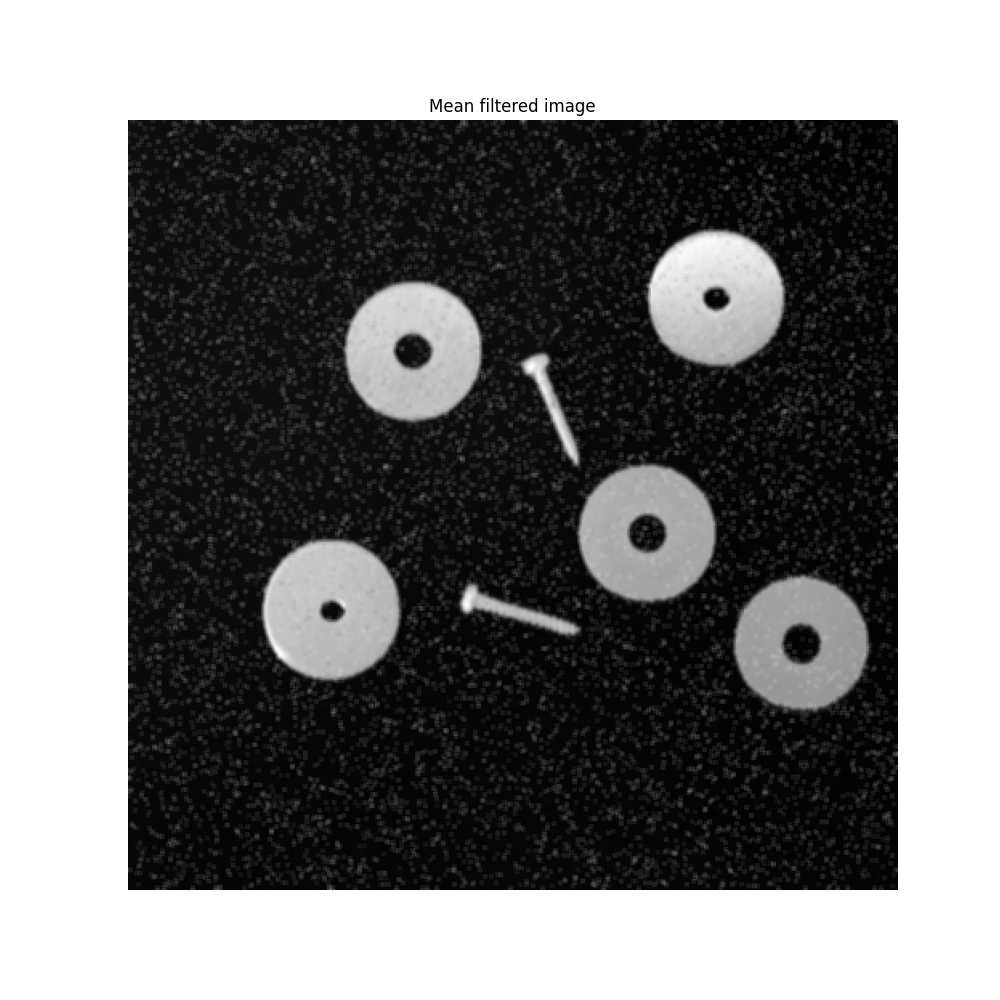

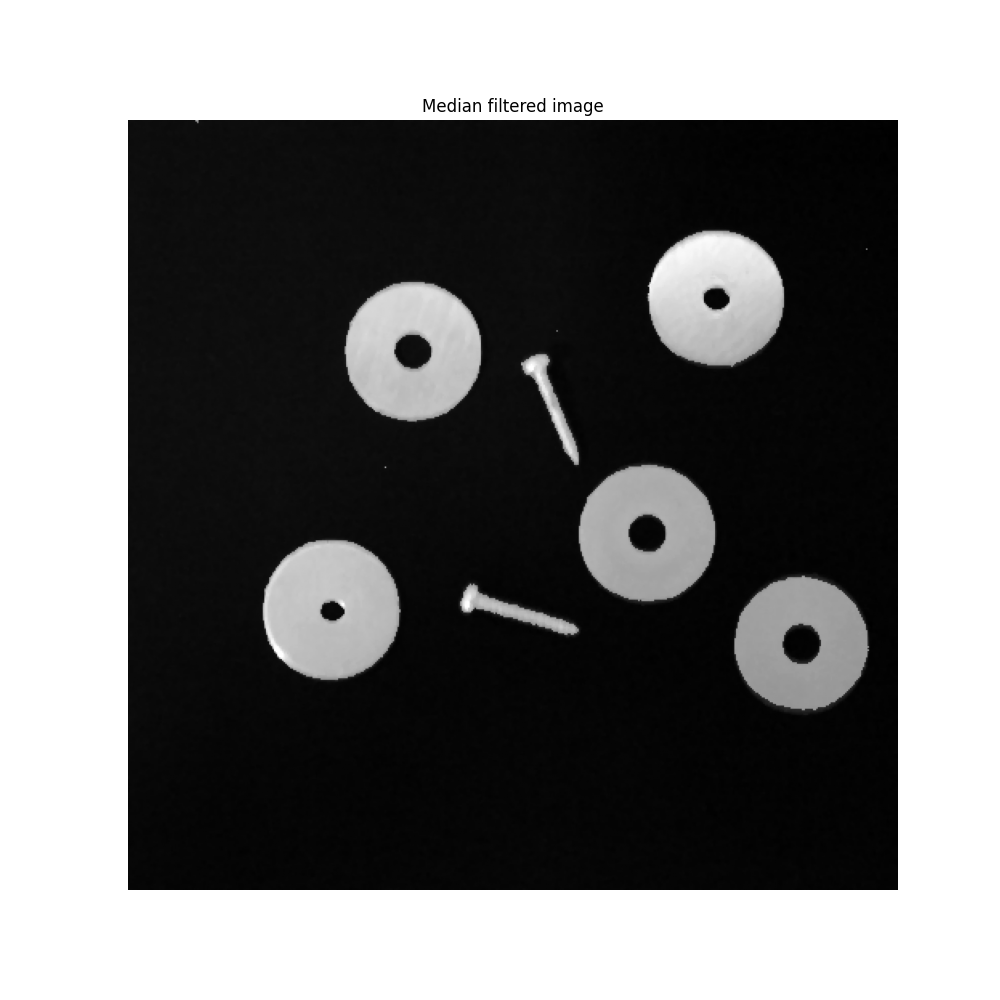

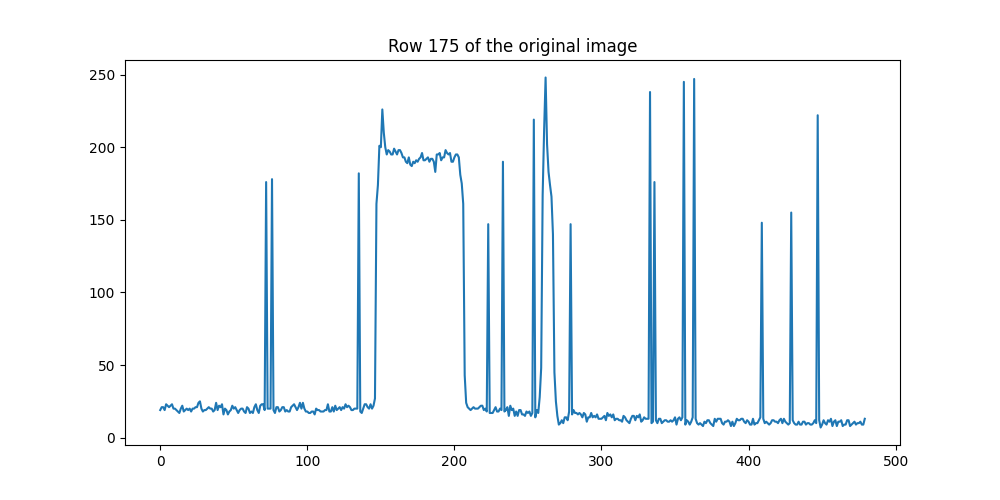

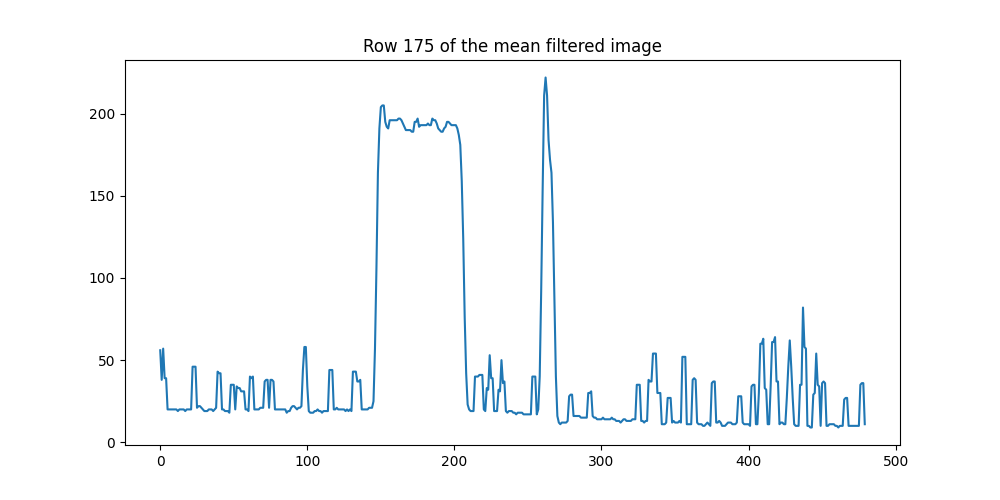

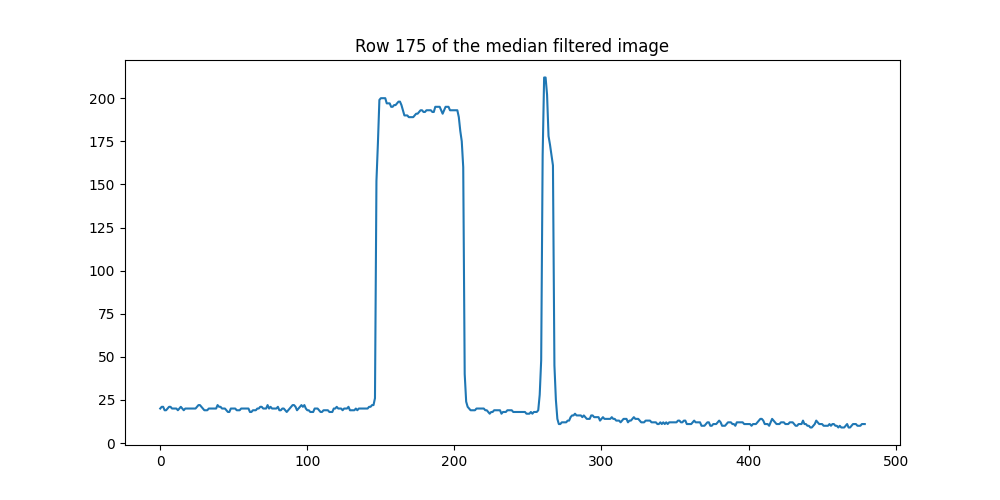

In [3]:
# image reading
im = cv.imread('../standard_test_images/tapis.png')
print ('image size =', np.shape(im)) 

im = im[:,:,1] # lus comme une image couleur ? 
print ('image size =', np.shape(im)) 
print ('pixel type =', im.dtype)

# image display
plt.figure(figsize=(10, 10))
plt.imshow(im, cmap='gray')
plt.title('Original image')
plt.axis('off')
plt.show()

# Filtering by using a mean filter (3x3) 

## kernel
kernel1 = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]) / 9

## filtering 
im_mean = cv.filter2D(im, -1, kernel1)


# image display
plt.figure(figsize=(10, 10))
plt.imshow(im_mean, cmap='gray')
plt.title('Mean filtered image')
plt.axis('off')
plt.show()

# Filtering by using a median filter (3x3) 
im_median = cv.medianBlur(im, 3)


# image display
plt.figure(figsize=(10, 10))
plt.imshow(im_median, cmap='gray')
plt.title('Median filtered image')
plt.axis('off')
plt.show()


# Display of the 175th rows 
plt.figure(figsize=(10, 5))
plt.plot(im[175, :])
plt.title('Row 175 of the original image')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(im_mean[175, :])
plt.title('Row 175 of the mean filtered image')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(im_median[175, :])
plt.title('Row 175 of the median filtered image')
plt.show()



**Questions:**
   
* What are the characteristics of this "salt-and-pepper" noise? 
* Why the median filter is more efficient in this case? How does it work?

**Responses:**
   
   

1.Il peut occasionnellement présenter des points extrêmement lumineux ou sombres de manière anormale.

Le bruit est distribué de manière clairsemée.Il n’affecte pas chaque pixel mais apparaît aléatoirement,la plupart des valeurs restant inchangées.

Les valeurs des pixels bruités présentent des variations brusques et importantes par rapport à celles des pixels normaux environnants.

2.En effet,le filtre médian trie les valeurs des pixels dans la fenêtre et élimine les valeurs extrêmes dues au bruit,contrairement au filtre moyen qui effectue une moyenne entre les valeurs normales et le bruit environnant,ce qui a pour effet de flouter les données.De plus,le filtre médian préserve mieux les contours de l’image que le filtre moyen.

how it work?

Il utilise une fenêtre qui se déplace sur l’image,puis extrait les valeurs de gris des pixels couverts par cette fenêtre et les trie dans l’ordre croissant.Ensuite,il sélectionne la valeur centrale et remplace la valeur du pixel au centre de la fenêtre par cette médiane.





### Binarization 

By using the Otsu's method, determine the threshold in order to binarize the image filtered. 

Check that the resul is correct such as background's pixels are equal to 0, form's pixels are equal to 1. 

Note that OpenCV will use images in uint8 format (and not boolean) in the following steps. 


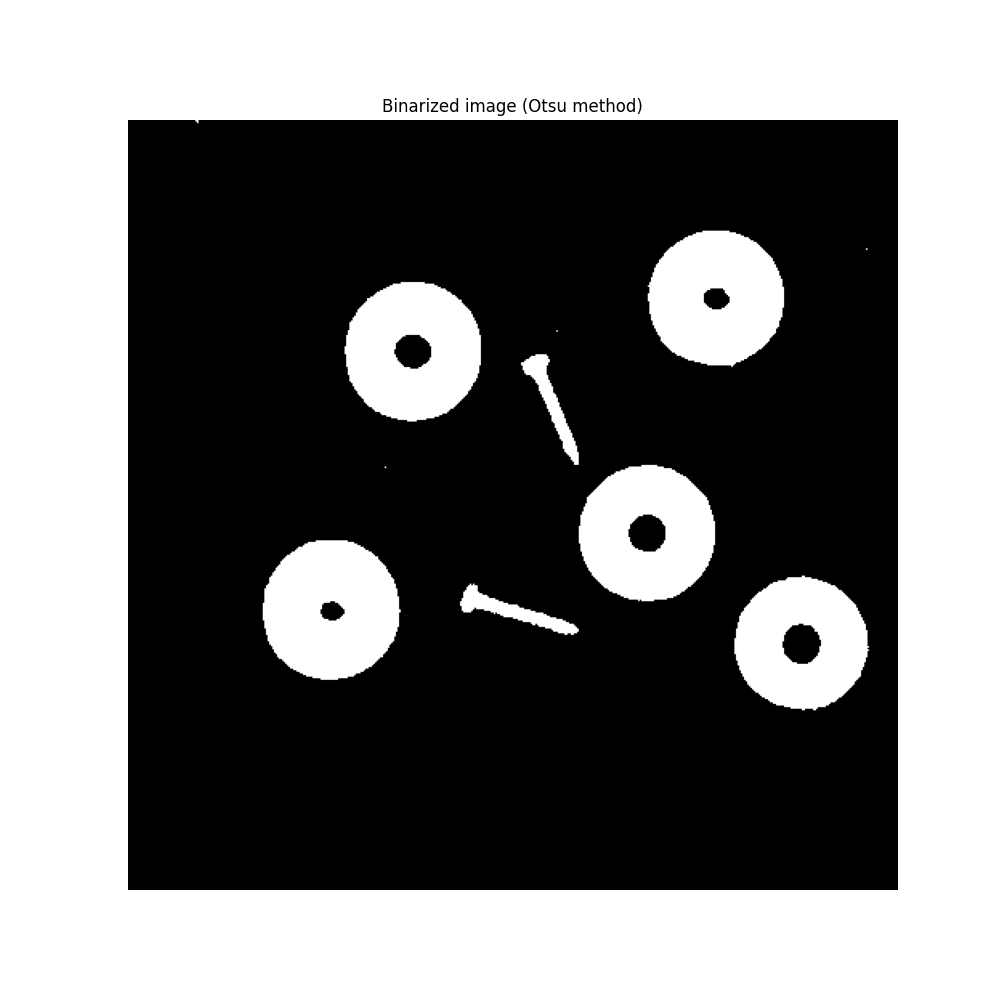

number of rows = 480
number of columns = 480


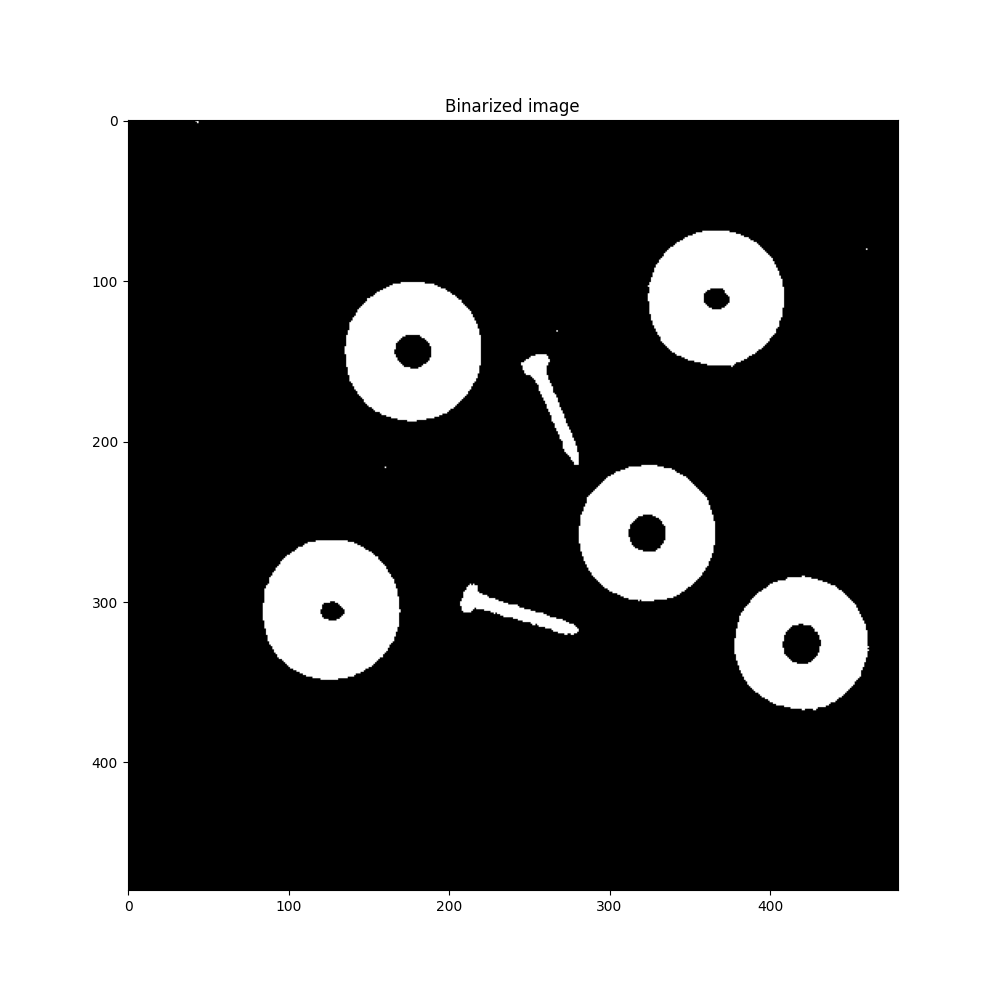

In [4]:
# "Binarization" with an automatic threshold (by Otsu method)
(thresh, im_otsu) = cv.threshold(im_median, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
# image display
plt.figure(figsize=(10, 10))
plt.title('Binarized image (Otsu method)')
plt.imshow(im_otsu, cmap='gray')
plt.axis('off')
plt.show()

nb_rows=np.size(im,0)
nb_cols=np.size(im,1)
print('number of rows =', nb_rows)
print('number of columns =', nb_cols) 
im_otsu[np.where(im_otsu == 0)] = 0 # for the display of the histogram
im_otsu[np.where(im_otsu == 255)] = 1
plt.figure(figsize=(10, 10))
plt.title('Binarized image')
plt.imshow(im_otsu, cmap='gray')
plt.show()





## Mathematical morphology operations on binary images

### Removing of the screws

To remove the screws from the "binary image", proceed in 2 steps:
- first, one single erosion removes all the screw (but also the rings), 
- then by controlled successive dilations, the rings are reshaped.

Write the python code in order to:
* create a circular structural element with a large radius with _cv.getStructuringElement()_
* erode the "binary" image in order to remove the screws, with _cv.erode()_
* by successive dilations (using small circular structural element), reshape de rings, with _cv.dilate()_


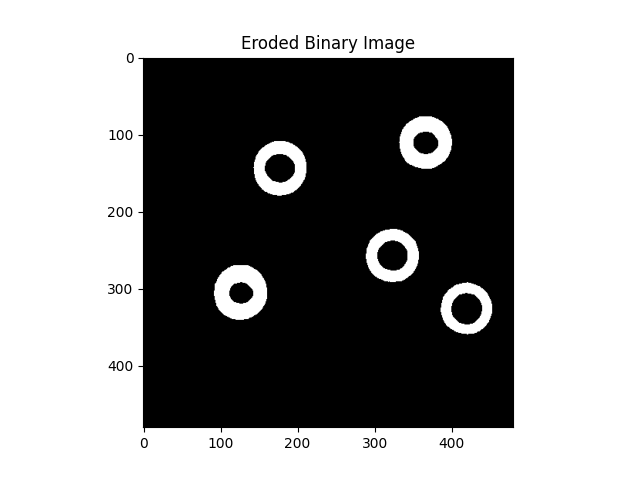

In [5]:
# RAZ (figures closing)
plt.close('all')

# Removing of the screws 

# circular structural element 
radius1 = 17; # radius of the circular structural element
B1=cv.getStructuringElement(cv.MORPH_ELLIPSE, (radius1, radius1))


# Erosion 
imbw_T = cv.erode(im_otsu, B1, iterations=1)

plt.figure()
plt.title('Eroded Binary Image')
plt.imshow(imbw_T, cmap='gray')

    

number of iterations = 4


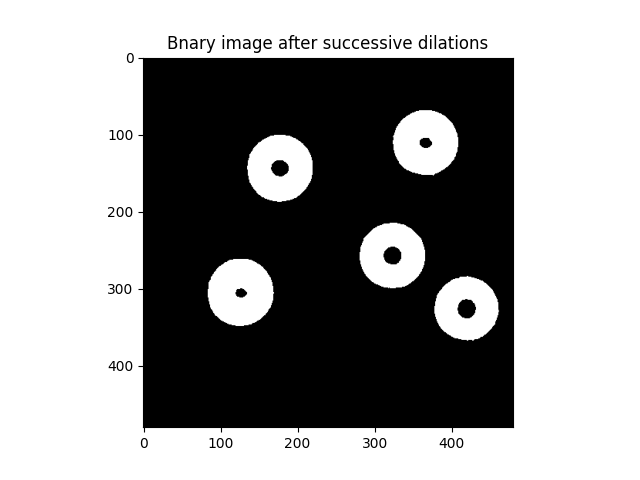

In [6]:
# Successives Dilations 

# initialisation
count = 0;
radius2 = 8 # radius of the circular structural element
B2=cv.getStructuringElement(cv.MORPH_ELLIPSE, (radius2, radius2))
# Structural element B2
im_tmp = cv.convertScaleAbs( np.zeros( np.shape(imbw_T) ) );

# Iterations up to idempotence
while( (cv.subtract(imbw_T, im_tmp).any()) ):
    count = count+1;
    im_tmp = imbw_T; # before dilation
    imbw_T = cv.dilate(imbw_T, B2, iterations=1)*im_otsu; # after dilation and masking by the binarized image
    plt.imshow(imbw_T, cmap='gray')
    plt.title('Dilated image (iteration {})'.format(count))
    time.sleep(1) # pause for visualization
    
# display 
plt.figure()
plt.imshow(imbw_T, cmap='gray')
plt.title('Bnary image after successive dilations')
print('number of iterations =', count)

**Questions:**
   
* How do you choose the structural element used for the erosion?   
* How do you choose the structural element used for the successive dilations? 
* What is the criteria used to stop the successive dilations? 

**Responses:**



1.La taille de l’élément structurant doit être strictement supérieure à la largeur maximale des objets que l’on souhaite supprimer, afin de garantir qu’ils soient complètement érodés jusqu’à 0 ; en même temps, elle doit être strictement inférieure à la largeur minimale des objets que l’on souhaite conserver, afin d’éviter qu’ils ne soient entièrement supprimés. De plus, sa forme doit généralement être similaire à la géométrie des objets présents dans l’image.

2.Nous utilisons généralement des éléments structurants très petits afin d’éviter qu’ils ne soient trop grands et ne franchissent de fines fissures ou de petits interstices.

3.Après chaque opération de dilatation suivie d’une intersection avec l’image originale, nous comparons le résultat courant avec celui de l’itération précédente. Si l’image actuelle est identique à celle de l’étape précédente, on arrête le processus.




### Segmentation and labelling of the objects

We are going to use the Rosenfeld algorithm in order to segment and count the objects in the binary image.
Complete the fonction below and test it:
- first on a small matrix (define just after)
- next, on the complete binary image.


In [7]:
def label(I_in):
    
    """
    Labelling of an binary image by using the Rosenfeld method. 
    Usage: 
    nb_objects, I_out = label(I_in)
    - I_in: input binary image 
    - nb_objects: number of connected objects obtained after segmentation
    - I_out: segmented output image  
    """
    
    # initialisation 
    
    nb_rows, nb_colums = np.shape(I_in); 
    
    # The table "labels" contains the pixels of the form.
    # The pixels are ranked as by a raster-scan of the image (i.e. from top-down, left-right). 
    # The table has 3 columns :
    # - 1st column: row index of the pixels
    # - 2nd colum: columns index
    # - label of the pixel
    
    # find the coordinates of the pixels equal to 1
    coords = cv.findNonZero(I_in) 
        # coordinates of the pixels equal to 1
        # Note: the indexes rows/columns returned here are inversed (column index first)
    nb_pixels_1 = np.shape(coords)[0] # nb of pixels equals to 1 (that belong to the form)
    
    # labels filling with the form's pixels coordinates
    labels = np.zeros([nb_pixels_1, 3]).astype(int) # creations
    coords_flatten = coords.flatten()  # all the coordinates in one column (1D)
    labels[0:, 0] = coords_flatten[1::2] # row indexes of the form pixelss
    labels[0:, 1] = coords_flatten[0::2] # column indexes of the form pixels
    
    # labels filling: computation of the form's pixels labels
    
    # initialisation of the labels 
    labels[0:, 2] = -1 # labels initialisation: "-1" = no label 
    labels[0, 2] = 1 # for the first pixel => label = 1 (note: the background label is 0)
    
    # then scan of the other pixels in labels:

    for m in range(1, nb_pixels_1): # m: index of the current pixel
                
        # coordinates of the current pixels
        coord_Cr = labels[m, 0]; # rows index 
        coord_Cc = labels[m, 1]; # columns index
        
        # coordinates of its left neighbour
        coord_Lr = coord_Cr; # rows index of the left neighbour
        coord_Lc = coord_Cc - 1; # columns index of the left neighbour

            
        # coordinates of its top neighbour
        
        coord_Tr = coord_Cr - 1; # rows index of the top neighbour
        coord_Tc = coord_Cc; # columns index of the top neighbour
        
        # research of an (eventual) left neighbour 
        # between the previous pixels in "labels"
        
        index_neighbour_L = -1; # initialisation : no left neighbour in labels
        
        eventual_neigbours_Lr = np.where( labels[0:m, 0]==coord_Lr )[0] # possibility in labels
        nb_eventual_neigbours_Lr = np.size( eventual_neigbours_Lr )
        
        if (nb_eventual_neigbours_Lr > 0):              
            eventual_neigbour_Lc = np.where( labels[ eventual_neigbours_Lr, 1]==coord_Lc )[0];
            nb_eventual_neigbours_Lc = np.size( eventual_neigbour_Lc )
            
            if (nb_eventual_neigbours_Lc > 0): 
                index_neighbour_L = eventual_neigbours_Lr[ eventual_neigbour_Lc[0] ]
                
        # research of an (eventual) top neighbour 
        # between the previous pixels in "labels"
        
        index_neighbour_T = -1; # initialisation : no top neighbour in labels
        eventual_neigbours_Tr = np.where( labels[0:m, 0]==coord_Tr )[0] # possibility in labels
        nb_eventual_neigbours_Tr = np.size( eventual_neigbours_Tr )
        if (nb_eventual_neigbours_Tr > 0):
            eventual_neigbour_Tc = np.where( labels[ eventual_neigbours_Tr, 1]==coord_Tc )[0];
            nb_eventual_neigbours_Tc = np.size( eventual_neigbour_Tc )
            
            if (nb_eventual_neigbours_Tc > 0): 
                index_neighbour_T = eventual_neigbours_Tr[ eventual_neigbour_Tc[0] ]

               
        # labeling according to the neigbours 
        
        # if the current pixel has a Left neighbour AND a top neighbour 
        if (( index_neighbour_L != -1) and ( index_neighbour_T != -1)):
            label_min = np.min( [ labels[index_neighbour_L][2], labels[index_neighbour_T][2] ] );
            label_max = np.max( [ labels[index_neighbour_L][2], labels[index_neighbour_T][2] ] );
             #TO COMPLETE # label for  the current pixel
            labels[m][2] = label_min
            
            # if the 2 labels are different for the connected pixels => previous labels actualisation
            if (label_min != label_max):  
                for j in range(1,m): # pixels connected with the current one => label_min
                    if ( labels[j][2] == label_max):
                         #TO COMPLETE
                         labels[j][2] = label_min
                    if ( labels[j][2] > label_max): # pixels not connected with the current one and with a higher label
                         #TO COMPLETE # these labels have to be decremented
                         labels[j][2] = labels[j][2] - 1
                    
        
        # if the current pixel has only a Left neighbour
        elif (index_neighbour_L != -1):
             #TO COMPLETE # current pixel label = label of its left neighbour
            labels[m][2] = labels[index_neighbour_L][2]
 
        # if the current pixel has only a top neighbour 
        elif (index_neighbour_T != -1):  
              #TO COMPLETE # current pixel label = label of its top neighbour
            labels[m][2] = labels[index_neighbour_T][2]
        # if the current pixel has no neighbour
        else:
            label_max = -1
            for j in range(1,m): # find the max label among the previous
                if( labels[j][2] > label_max): 
                    label_max = labels[j][2]
             #TO COMPLETE # new label by incrementation of the max label 
            labels[m][2] = label_max + 1
                   
    # objects number and segmented image
    
    # initialisations
    nb_objects = 0
    I_out = ( np.zeros([nb_rows, nb_colums])).astype(int); # segmented image (output)
    
    # scan of labels 
    for m in range(0, nb_pixels_1):
        
        xx = labels[m][0]; # pixel row index
        yy = labels[m][1]; # pixel column index
        #TO COMPLETE # pixel label
        I_out[xx][yy] = labels[m][2] # pixel label in the segmented image

        if( labels[m][2] > nb_objects): 
            nb_objects = labels[m][2]
                    
    return nb_objects, I_out #I_out, nb_obj  
          

AA = 
[[1 1 0 0 0 0]
 [0 0 1 0 1 0]
 [0 1 0 1 1 0]
 [0 0 0 0 0 0]]
nb_obj=  4


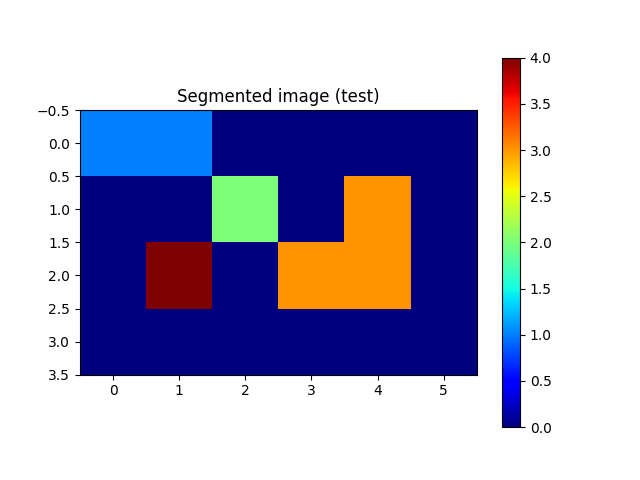

In [8]:
# tests on a small binary image 

# synthesis of the binary image AA
AA = (np.zeros([4, 6])).astype(int);
AA[0,0]=1
AA[0,1]=1
AA[1,2]=1
AA[2,1]=1
AA[1,4]=1
AA[2,4]=1
AA[2,3]=1

print("AA = ")
print(AA)

# segmentation and labelling of AA (and objects counting)
nb_obj, I_seg = label(AA)

# results display
print("nb_obj= ", nb_obj)

plt.figure()
plt.title('Segmented image (test)')
plt.imshow(I_seg, cmap='jet')
plt.colorbar()


Number of labels = 5


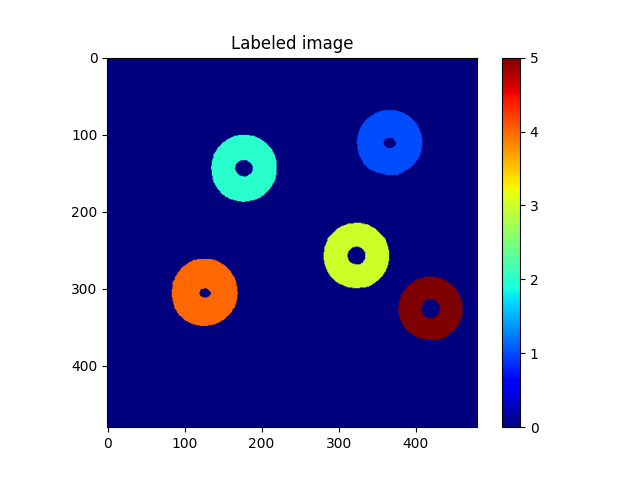

In [9]:
# RAZ (figures closing)
plt.close('all')

# segmentation and labelling of the binary image with the rings (and counting of the laters)
nb_objects, labels = label(imbw_T)

    
# display 
print('Number of labels =', nb_objects)
plt.figure()
plt.title('Labeled image')
plt.imshow(labels, cmap='jet')
plt.colorbar()

**Questions:**

We consider the _labels_ matrix define in the _label()_ function, 
and _m_ is the processed current pixel:
- How do you get the coordinates of the left neighbour of m?
- How do you get the coordinates of the top neighbour of m?
- Is it an issue if the computed coordinates of the neighbour of _m_ is outside the image border?  
- What is the label of _m_ if it has 2 neighbours (left and top) with the same label? 
- What is the label of _m_ if it has 2 neighbours (left and top) with different labels? What operation is then necessary for the pixels not connected with _m_ and such as their label is higher than _m_'s label?
- What is the label of _m_ if it has only one left neighbour?
- What is the label of _m_ if it has only one top neighbour?
- What is the label of _m_ if it has no neighbour?
- Why does the Rosenfeld's method compute also the number of connected objects? What is the requirement for the background's label?

**Responses:**



1.linge indice: coord_Lr=coord_Cr      Colonne indice: coord_Lc=coord_Cc-1

2.linge indice: coord_Tr=coord_Cr-1    Colonne indice: coord_Tc=coord_Cc

3.Non,il n'y a pas de problèm.Il n’utilise pas directement ces coordonnées pour indexer la matrice de l’image originale,i les coordonnées sont en dehors des limites, np.where renvoie simplement un tableau vide.

4.Le pixel m héritera directement de ce même label.

5.m prendra la plus petite valeur parmi les étiquettes de ses deux voisins. Il est nécessaire de parcourir tous les pixels déjà traités et de remplacer les étiquettes ayant initialement la valeur max par min. Par ailleurs, afin de garantir la continuité des étiquettes, toutes les étiquettes strictement supérieures à max doivent être décrémentées de 1.

6.Le pixel m hérite directement de l’étiquette de son voisin de gauche.

7.Le pixel m hérite directement de l’étiquette de son voisin supérieur.

8.Le pixel m aura une nouvelle étiquette, égale à la valeur maximale des étiquettes déjà présentes dans l’image, augmentée de 1.

9.Parce que chaque fois qu’un pixel sans voisins déjà étiquetés est rencontré, l’algorithme lui attribue un nouveau label unique et incrémenté. À la fin du traitement, le plus grand label correspond directement au nombre total d’objets connectés.Et,Le fond doit avoir un label spécial et ne pas être compté comme un objet.



## Morphological mathematic operations on gray image 

Write the code in order to: 
- load the _cameraman.png_ image
- erode, dilate, open or close the original by using a circular structural element
- display side-by-side the eroded / opened images
- display side-by-side the dilated / closed images

image size = (256, 256)
pixel type = float32


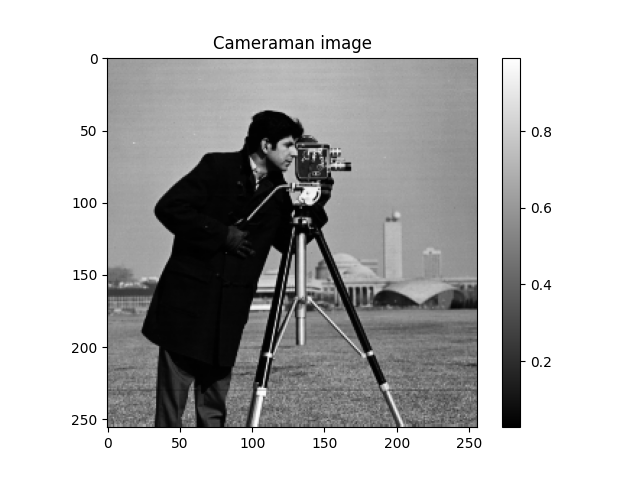

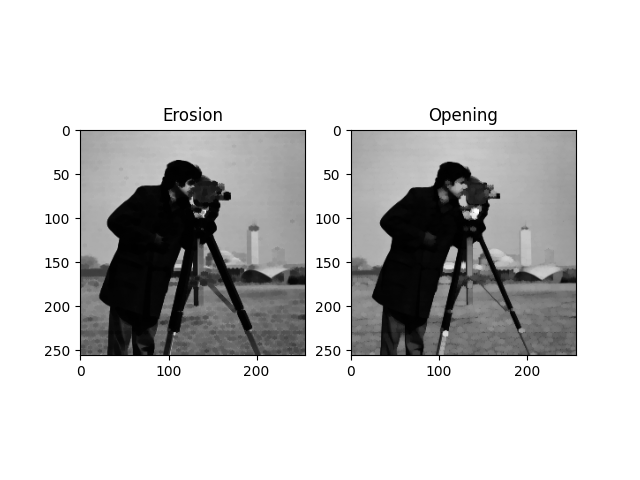

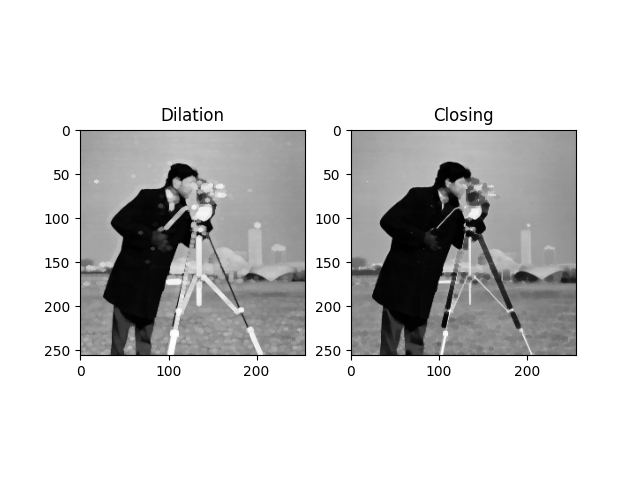

In [10]:
# RAZ (figures closing)
plt.close('all')

# loading
im = plt.imread('../standard_test_images/cameraman.png')

# image size and pixel type 
print ('image size =', np.shape(im)) 
print ('pixel type =', im.dtype)

# display
plt.figure()
plt.title('Cameraman image')
plt.imshow(im, cmap='gray')
plt.colorbar()

# circular structural element
radius = 5
structuring_element = cv.getStructuringElement(cv.MORPH_ELLIPSE, (radius, radius))


# erosion 
im_erosion = cv.erode(im, structuring_element)

# opening 
im_opening = cv.morphologyEx(im, cv.MORPH_OPEN, structuring_element)

# display 
ig,axs=plt.subplots(1, 2)
axs[0].title.set_text('Erosion')
axs[0].imshow(im_erosion, cmap='gray')
axs[1].title.set_text('Opening')
axs[1].imshow(im_opening, cmap='gray')


# dilation 
im_dilation = cv.dilate(im, structuring_element)

# closing
im_closing = cv.morphologyEx(im, cv.MORPH_CLOSE, structuring_element)

# display 
ig,axs=plt.subplots(1, 2)
axs[0].title.set_text('Dilation')
axs[0].imshow(im_dilation, cmap='gray')
axs[1].title.set_text('Closing')
axs[1].imshow(im_closing, cmap='gray')

**Questions:**
- What are the mathematical definitions of these morphological operations (when used on gray images)?
- Explain the effects on the images? 

**Responses:**


1.Grayscale Erosion:$$(f \ominus b)(x, y) = \min_{(s, t) \in B} \{ f(x + s, y + t) \}$$

Grayscale Dilation: $$(f \oplus b)(x, y) = \max_{(s, t) \in B} \{ f(x - s, y - t) \}$$

Grayscale Opening: $$(f \circ b)(x, y) = (f \ominus b) \oplus b$$

Grayscale Closing: $$(f \bullet b)(x, y) = (f \oplus b) \ominus b$$

2.Erosion:Il agrandit les régions sombres et réduit les régions claires. L’image globale devient plus sombre. Les petits détails lumineux de l’image sont atténués ou supprimés.

Dilation:Il agrandit les régions claires et réduit les régions sombres. L’image globale devient plus lumineuse. Les petits détails sombres de l’image sont comblés ou disparaissent.

Opening:La luminosité globale de l’image reste globalement inchangée, mais il supprime les petits détails lumineux ou les points lumineux isolés.

Closing:Tout en préservant les contours globaux de l’image, il comble les petits trous sombres ou les fines fissures.




